In [1]:
import shap

print(shap.__version__)

0.52.0


In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/PS_20174392719_1491204439457_log.csv"
)

df = df.drop(
    columns=[
        'nameOrig',
        'nameDest'
    ]
)

df['balance_change_orig'] = (
    df['oldbalanceOrg']
    -
    df['newbalanceOrig']
)

df['balance_change_dest'] = (
    df['newbalanceDest']
    -
    df['oldbalanceDest']
)

df['amount_balance_ratio'] = (
    df['amount']
    /
    (df['oldbalanceOrg'] + 1)
)

In [4]:
X = df.drop(
    columns=['isFraud']
)

y = df['isFraud']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
X_train_sample = X_train.sample(
    n=500000,
    random_state=42
)

y_train_sample = y_train.loc[
    X_train_sample.index
]

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

categorical_features = ['type']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=100,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train_sample,
    y_train_sample
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['step','type','amount',...,'balance_change_orig','balance_change_dest', 'amount_balance_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [8]:
X_test_small = X_test.head(1000)


In [9]:
X_test_transformed = (
    rf_model.named_steps['preprocessor']
    .transform(X_test_small)
)

In [10]:
explainer = shap.TreeExplainer(
    rf_model.named_steps['classifier']
)

In [11]:
shap_values = explainer.shap_values(
    X_test_transformed
)

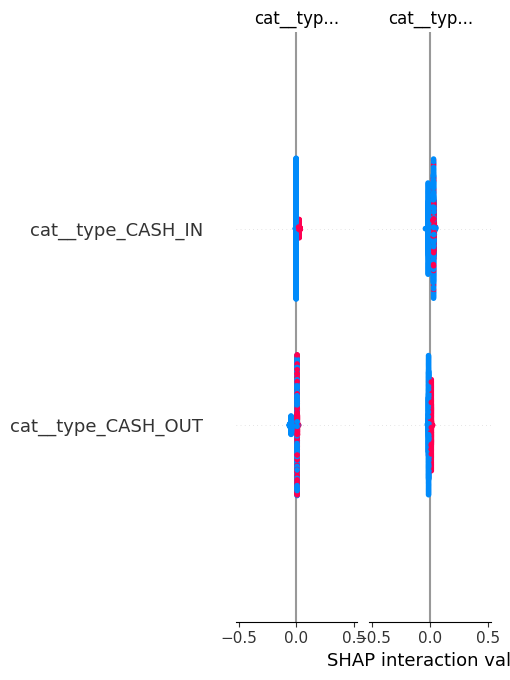

In [12]:
feature_names = (
    rf_model.named_steps['preprocessor']
    .get_feature_names_out()
)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [13]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [14]:
print(len(shap_values))

1000


In [15]:
print(shap_values.shape)

(1000, 15, 2)


In [16]:
print(shap_values.shape)

(1000, 15, 2)


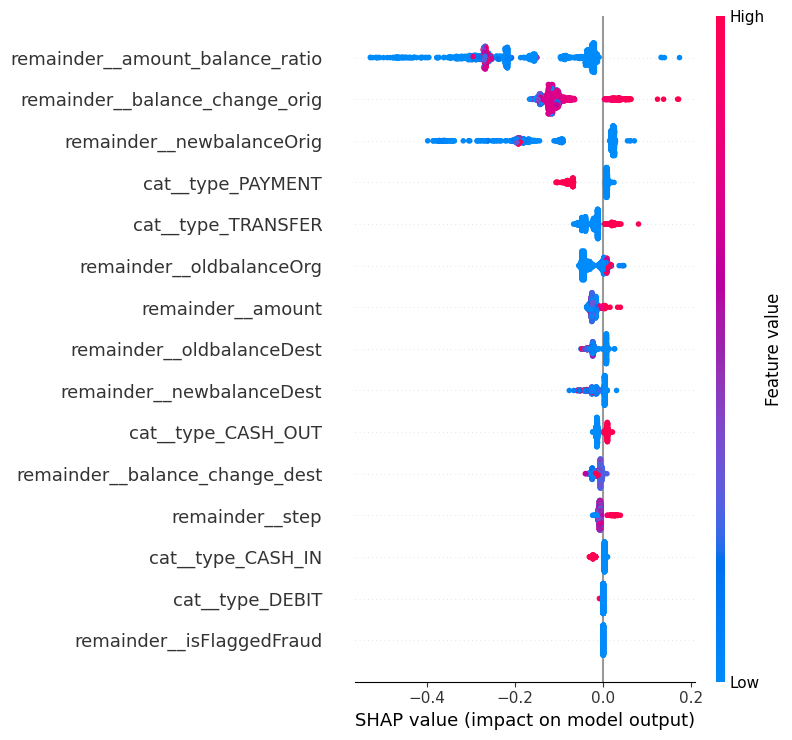

In [17]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)

In [18]:
fraud_indices = y_test[y_test == 1].index

sample_index = fraud_indices[0]

print(sample_index)

6202693


In [19]:
sample_row = X.loc[[sample_index]]

sample_row

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_change_orig,balance_change_dest,amount_balance_ratio
6202693,583,CASH_OUT,759701.03,759701.03,0.0,1076095.67,1835796.71,0,759701.03,759701.04,0.999999


In [20]:
sample_transformed = (
    rf_model.named_steps['preprocessor']
    .transform(sample_row)
)

In [21]:
sample_shap = explainer.shap_values(
    sample_transformed
)

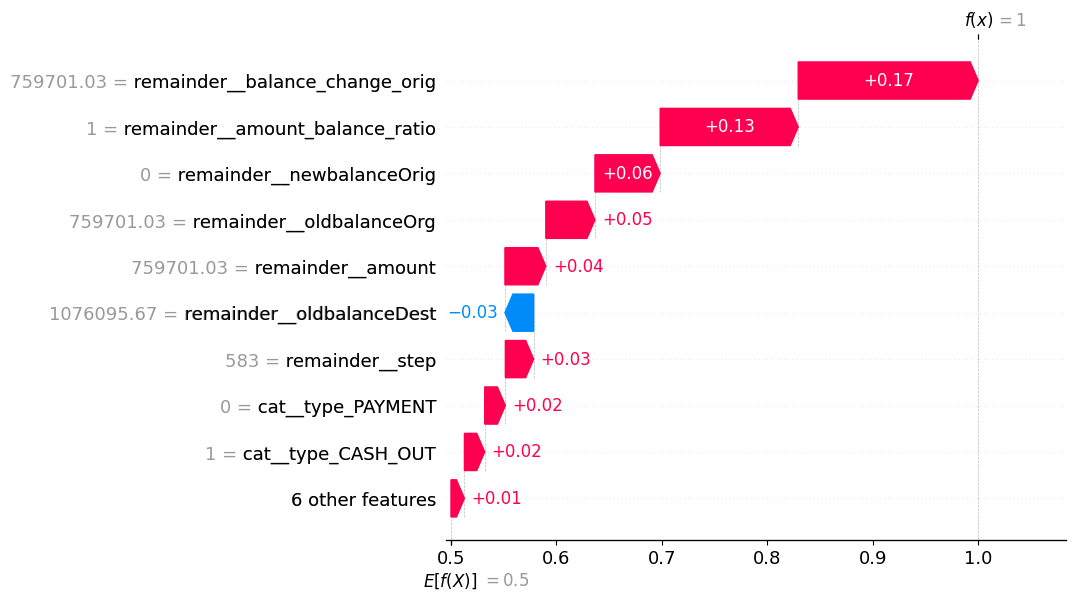

In [22]:
shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap[0,:,1],
        base_values=explainer.expected_value[1],
        data=sample_transformed[0],
        feature_names=feature_names
    )
)

In [23]:
sample_row

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_change_orig,balance_change_dest,amount_balance_ratio
6202693,583,CASH_OUT,759701.03,759701.03,0.0,1076095.67,1835796.71,0,759701.03,759701.04,0.999999


In [24]:
sample_transformed = (
    rf_model.named_steps['preprocessor']
    .transform(sample_row)
)

In [25]:
sample_shap = explainer.shap_values(
    sample_transformed
)

In [26]:
print(sample_shap.shape)

(1, 15, 2)


In [27]:
print(explainer.expected_value)

[0.49999618 0.50000382]


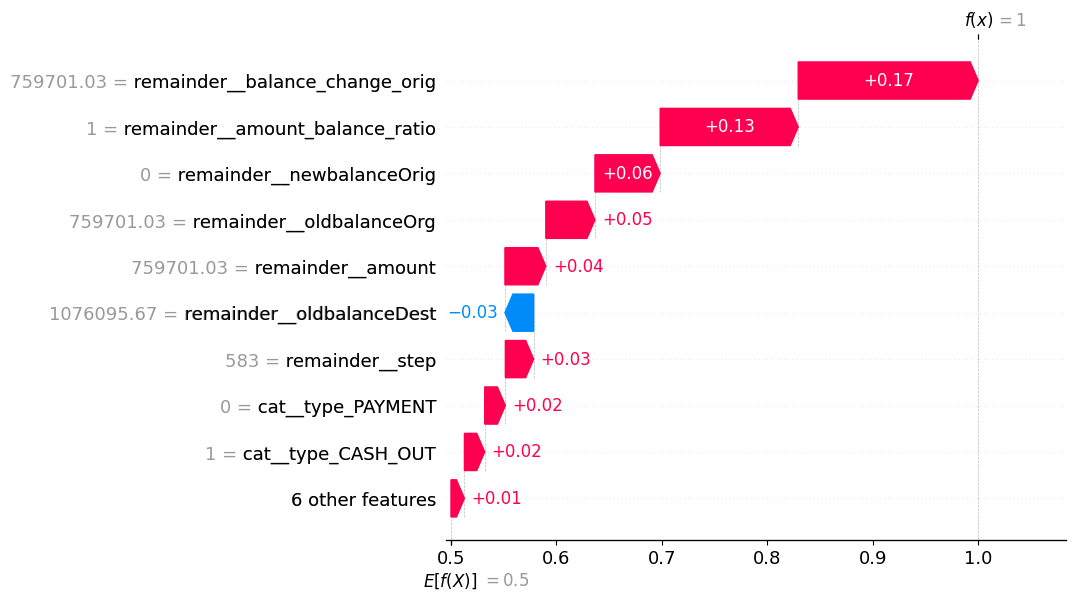

In [28]:
shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap[0, :, 1],
        base_values=explainer.expected_value[1],
        data=sample_transformed[0],
        feature_names=feature_names
    )
)